In [67]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
from tweezepy import allanvar as tpy
import scipy

In [68]:
def process_data(data_txt):
    # Read data
    cols = ['MJD','R.A. (mas)', 'Dec. (mas)', 'Err. R.A. (mas)', 'Err. Dec. (mas)', 'Corr.', 'Del.']
    cols_widths = [(0,9),(9,26),(27,46),(47,56),(57,66),(67,74),(75,79)]
    df = pd.read_fwf(data_txt, colspecs=cols_widths, skiprows=4, header=None, names=cols) 
    
    # Convert to float
    df_new = df.apply(pd.to_numeric, errors='coerce').dropna()    
    
    # Convert from mas to microas
    df_new['R.A. (micas)'] = df_new['R.A. (mas)']*1000
    df_new['Dec. (micas)'] = df_new['Dec. (mas)']*1000
    df_new['Err. R.A. (micas)'] = df_new['Err. R.A. (mas)']*1000
    df_new['Err. Dec. (micas)'] = df_new['Err. Dec. (mas)']*1000
    
    # Convert from mas to degrees to radian
    df_new['Dec. (rad)'] = (df_new['Dec. (mas)']/(3600*1000)).apply(np.deg2rad)
    
    # Calculate RA*cos(dec) column
    
    df_new['RAcosDEC'] = df_new['R.A. (micas)']*np.cos(df_new['Dec. (rad)'])
    
    # Calculate Besselian Year column
    df_new['BY'] = 2000-(51544.333981-df_new['MJD'])/365.242198781
    
    return df_new

In [69]:
df = process_data('ICRF3 Dem/series_ind_dem/1803+784_dem.txt')
df.head(5)

,MJD,R.A. (mas),Dec. (mas),Err. R.A. (mas),Err. Dec. (mas),Corr.,Del.,R.A. (micas),Dec. (micas),Err. R.A. (micas),Err. Dec. (micas),Dec. (rad),RAcosDEC,BY
0,45754.258,-1.910705,-1.887599,1.2912,0.7417,-0.084,40,-1910.704737,-1887.598813,1291.2,741.7,-9.151337e-09,-1910.704737,1984.147297
1,45759.251,-1.555439,-2.306200,1.2032,1.1362,0.028,19,-1555.438834,-2306.199571,1203.2,1136.2,-1.118077e-08,-1555.438834,1984.160968
2,45764.244,0.049960,1.459800,0.7069,0.6182,0.325,21,49.959984,1459.800012,706.9,618.2,7.077310e-09,49.959984,1984.174638
3,45769.259,-5.739611,0.890402,2.5316,1.1073,-0.363,25,-5739.611378,890.402401,2531.6,1107.3,4.316793e-09,-5739.611378,1984.188369
4,45864.264,-2.973084,0.696002,0.6484,0.6307,0.547,27,-2973.083789,696.002411,648.4,630.7,3.374315e-09,-2973.083789,1984.448484


In [97]:
len(df)

2732

In [98]:
df_sel = df[df['BY'] < 2015]
len(df_sel)

2234

# Using Tweezepy

In [70]:
def allanoadev_new(y,t,error):
        
    # === Parameters ===
    
    # Length of observation
    N = len(y)
        
    # m array where 3 < m < N/3 
    m = np.arange(3,1+round(N//3),1)
    # initial sampling time
    tau0 =  np.mean(np.diff(t))
    # steps
    step = tau0
    
    # Empty variance array
    allanvar = []
    # Empty tau values array 
    tau = []
    
    edfs = np.empty(len(m))

    # Iterate over values of m
    for k in range(len(m)): 
        # Sliding windows 
        left = min(t)
        right = min(t) + m[k]*tau0

        # Array for averages
        ybar = []

        # Array for amount of data points
        Nrray = []

        # Define no of windows with <= 2 data points
        nconstraint = 2
                
        # Check for missing windows 
        while right <= max(t):
            data_values = y[(t>=left) & (t<=right)]
            Ndata = len(data_values)
            Nrray.append(Ndata)

            if Ndata == 0:
                ybar.append(np.nan)
            else:
                if error is None: 
                    avg = np.average(data_values)
                    ybar.append(avg)
                else:
                    weights_std = 1/error[(t>=left) & (t<=right)]**2
                    avg = np.average(data_values, weights=weights_std)
                    ybar.append(avg)
            left += step 
            right += step    

        # Define empty windows 
        Nrray = np.array(Nrray)
        ybar = np.array(ybar)
        
        D = len(ybar[Nrray<=nconstraint])
        M = len(ybar)
        print(k,len(m),M,D)

        # Discard windows with too few data points
        ybar = ybar[Nrray>nconstraint]

        # Calculate allan var 
        outersum = []
        j = 0
        while j < M-2*m[k]+1-D:
            i = j
            innersum = []
            while i <= j+m[k]-1:
                innersum.append(ybar[i+m[k]]-ybar[i])
                i += 1
            outersum.append(0.5*(np.sum(innersum)/m[k])**2)
            j += 1


        # Calculate allan variance
        allanvar.append(np.sum(outersum)/(M-2*m[k]+1-D))
        
        # Calculate tau
        tau.append(tau0*m[k])
        
        # Calculate edf
        if N // m[k] > 32:
            alpha_int = tpy.noise_id(y,m[k])[0]
            print(alpha_int)
        if (alpha_int<3) and (alpha_int>-3):
            edfs[k] = tpy.edf_greenhall(alpha_int,2,m[k],N,overlapping=True)
        else:
            edfs[k] = tpy.edf_approx(N,m[k])

    # Calculate allan std dev
    allanstd = np.sqrt(allanvar)
        
    return tau, allanstd, edfs


In [99]:
%%time
tau_dec_new, allanstd_dec_new, edfs_dec = allanoadev_new(df_sel['Dec. (micas)'].values,df_sel['MJD'].values,df_sel['Err. Dec. (micas)'].values)

0 742 2230 929
0
1 742 2229 512
0
2 742 2228 372
0
3 742 2227 280
0
4 742 2226 214
0
5 742 2225 171
0
6 742 2224 143
0
7 742 2223 123
0
8 742 2222 107
0
9 742 2221 91
0
10 742 2220 77
0
11 742 2219 65
0
12 742 2218 55
0
13 742 2217 46
0
14 742 2216 36
0
15 742 2215 28
0
16 742 2214 19
0
17 742 2213 13
0
18 742 2212 7
0
19 742 2211 4
0
20 742 2210 3
0
21 742 2209 2
0
22 742 2208 1
0
23 742 2207 0
0
24 742 2206 0
0
25 742 2205 0
0
26 742 2204 0
0
27 742 2203 0
0
28 742 2202 0
0
29 742 2201 0
0
30 742 2200 0
0
31 742 2199 0
0
32 742 2198 0
0
33 742 2197 0
0
34 742 2196 0
0
35 742 2195 0
0
36 742 2194 0
0
37 742 2193 0
0
38 742 2192 0
0
39 742 2191 0
0
40 742 2190 0
0
41 742 2189 0
0
42 742 2188 0
0
43 742 2187 0
0
44 742 2186 0
0
45 742 2185 0
0
46 742 2184 0
0
47 742 2183 0
0
48 742 2182 0
0
49 742 2181 0
0
50 742 2180 0
0
51 742 2179 0
0
52 742 2178 0
0
53 742 2177 0
0
54 742 2176 0
0
55 742 2175 0
0
56 742 2174 0
0
57 742 2173 0
0
58 742 2172 0
0
59 742 2171 0
0
60 742 2170 0
0
61 742 

In [114]:
def process_allan(y,tau,edfs):
    tau_year = [x/365.242198781 for x in tau]
    samplevar = scipy.stats.variation(y)
    bottom = edfs*samplevar/scipy.stats.chi2.ppf(1-0.1/2,edfs)
    top = scipy.stats.chi2.ppf(0.1/2,edfs)
    top_alt = edfs*samplevar/scipy.stats.chi2.ppf(0.1/2,edfs)
    return tau_year,bottom,top,top_alt

In [116]:
tau_dec_year, bottom_dec, top_dec, top_alt_dec = process_allan(df_sel['Dec. (micas)'].values,tau_dec_new,edfs_dec)

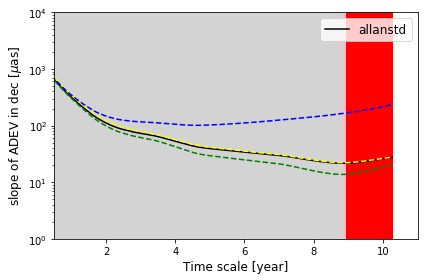

In [128]:
plt.figure()
# Calculate the slopes
slopes_dec = np.diff(np.log10(allanstd_dec_new)) / np.diff(np.log10(tau_dec_new))
# Plot allanstd
plt.plot(tau_dec_year,allanstd_dec_new,color='black',label='allanstd')
# Color background according to the slopes / noise type
plt.fill_between(tau_dec_year[1:], 1, 10**4, where= slopes_dec  < -0.25,color='lightgray',linewidth=1.0,zorder=1)
plt.fill_between(tau_dec_year[1:], 1, 10**4, where= (-0.25 <= slopes_dec ) & (slopes_dec  <= 0.25),color='pink',linewidth=1.0)
plt.fill_between(tau_dec_year[1:], 1, 10**4, where= slopes_dec  > 0.25,color='red',step='mid',linewidth=1.0)
# Plot confidence interval
plt.plot(tau_dec_year, allanstd_dec_new + bottom_dec,color='green',linestyle='dashed')
plt.plot(tau_dec_year, allanstd_dec_new + top_dec,color='yellow',linestyle='dashed')
plt.plot(tau_dec_year, allanstd_dec_new - top_alt_dec,color='blue',linestyle='dashed')

plt.yscale('log')
plt.xlabel('Time scale [year]', fontsize=12)
plt.ylabel(r'slope of ADEV in dec [$\mu$as]', fontsize=12)
plt.legend(fontsize=12)
plt.ylim(1,10**4)
plt.xlim(0.5,11)
plt.tight_layout()

In [108]:
%%time
tau_ra_new, allanstd_ra_new, edfs_ra = allanoadev_new(df_sel['RAcosDEC'].values,df_sel['MJD'].values,df_sel['Err. R.A. (micas)'].values)

0 742 2230 929
0
1 742 2229 512
0
2 742 2228 372
0
3 742 2227 280
0
4 742 2226 214
0
5 742 2225 171
0
6 742 2224 143
0
7 742 2223 123
0
8 742 2222 107
0
9 742 2221 91
0
10 742 2220 77
0
11 742 2219 65
0
12 742 2218 55
0
13 742 2217 46
0
14 742 2216 36
0
15 742 2215 28
0
16 742 2214 19
0
17 742 2213 13
0
18 742 2212 7
0
19 742 2211 4
0
20 742 2210 3
0
21 742 2209 2
0
22 742 2208 1
0
23 742 2207 0
0
24 742 2206 0
0
25 742 2205 0
0
26 742 2204 0
0
27 742 2203 0
0
28 742 2202 0
0
29 742 2201 0
0
30 742 2200 0
0
31 742 2199 0
0
32 742 2198 0
0
33 742 2197 0
0
34 742 2196 0
0
35 742 2195 0
0
36 742 2194 0
0
37 742 2193 0
0
38 742 2192 0
0
39 742 2191 0
0
40 742 2190 0
0
41 742 2189 0
0
42 742 2188 0
0
43 742 2187 0
0
44 742 2186 0
0
45 742 2185 0
0
46 742 2184 0
0
47 742 2183 0
0
48 742 2182 0
0
49 742 2181 0
0
50 742 2180 0
0
51 742 2179 0
0
52 742 2178 0
0
53 742 2177 0
0
54 742 2176 0
0
55 742 2175 0
0
56 742 2174 0
0
57 742 2173 0
0
58 742 2172 0
0
59 742 2171 0
0
60 742 2170 0
0
61 742 

In [118]:
tau_ra_year, bottom_ra, top_ra, top_alt_ra = process_allan(df_sel['RAcosDEC'].values,tau_ra_new,edfs_ra)

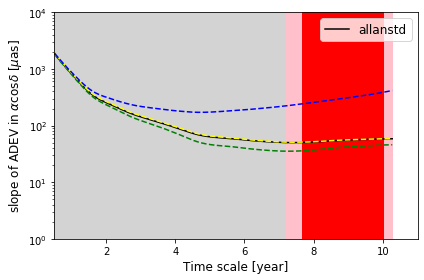

In [134]:
plt.figure()
# Calculate the slopes
slopes_ra = np.diff(np.log10(allanstd_ra_new)) / np.diff(np.log10(tau_ra_new))
# Plot allanstd
plt.plot(tau_ra_year,allanstd_ra_new,color='black',label='allanstd')
# Color background according to the slopes / noise type
plt.fill_between(tau_ra_year[1:], 1, 10**4, where= slopes_ra  < -0.25,color='lightgray',linewidth=1.0,zorder=1)
plt.fill_between(tau_ra_year[1:], 1, 10**4, where= (-0.25 <= slopes_ra ) & (slopes_ra  <= 0.25),color='pink',linewidth=1.0)
plt.fill_between(tau_ra_year[1:], 1, 10**4, where= slopes_ra  > 0.25,color='red',step='mid',linewidth=1.0)
# Plot confidence interval
plt.plot(tau_ra_year, allanstd_ra_new + bottom_ra,color='GREEN',linestyle='dashed')
plt.plot(tau_ra_year, allanstd_ra_new + top_ra,color='yellow',linestyle='dashed')
plt.plot(tau_ra_year, allanstd_ra_new - top_alt_ra,color='blue',linestyle='dashed')

plt.yscale('log')
plt.xlabel('Time scale [year]', fontsize=12)
plt.ylabel(r'slope of ADEV in $\alpha\cos{\delta}$ [$\mu$as]', fontsize=12)
plt.legend(fontsize=12)
plt.ylim(1,10**4)
plt.xlim(0.5,11)
plt.tight_layout()

# Using ybar for edf

In [129]:
def allanoadev_bar(y,t,error):
        
    # === Parameters ===
    
    # Length of observation
    N = len(y)
        
    # m array where 3 < m < N/3 
    m = np.arange(3,1+round(N//3),1)
    # initial sampling time
    tau0 =  np.mean(np.diff(t))
    # steps
    step = tau0
    
    # Empty variance array
    allanvar = []
    # Empty tau values array 
    tau = []
    
    edfs = np.empty(len(m))
    samplevar = np.empty(len(m))

    # Iterate over values of m
    for k in range(len(m)): 
        # Sliding windows 
        left = min(t)
        right = min(t) + m[k]*tau0

        # Array for averages
        ybar = []

        # Array for amount of data points
        Nrray = []

        # Define no of windows with <= 2 data points
        nconstraint = 2
                
        # Check for missing windows 
        while right <= max(t):
            data_values = y[(t>=left) & (t<=right)]
            Ndata = len(data_values)
            Nrray.append(Ndata)

            if Ndata == 0:
                ybar.append(np.nan)
            else:
                if error is None: 
                    avg = np.average(data_values)
                    ybar.append(avg)
                else:
                    weights_std = 1/error[(t>=left) & (t<=right)]**2
                    avg = np.average(data_values, weights=weights_std)
                    ybar.append(avg)
            left += step 
            right += step    

        # Define empty windows 
        Nrray = np.array(Nrray)
        ybar = np.array(ybar)
        
        D = len(ybar[Nrray<=nconstraint])
        M = len(ybar)
        print(k,len(m),M,D)

        # Discard windows with too few data points
        ybar = ybar[Nrray>nconstraint]

        # Calculate allan var 
        outersum = []
        j = 0
        while j < M-2*m[k]+1-D:
            i = j
            innersum = []
            while i <= j+m[k]-1:
                innersum.append(ybar[i+m[k]]-ybar[i])
                i += 1
            outersum.append(0.5*(np.sum(innersum)/m[k])**2)
            j += 1


        # Calculate allan variance
        allanvar.append(np.sum(outersum)/(M-2*m[k]+1-D))
        
        # Calculate tau
        tau.append(tau0*m[k])
        
        # Calculate edf
        if N // m[k] > 32:
            alpha_int = tpy.noise_id(ybar,m[k])[0]
            print(alpha_int)
        if (alpha_int<3) and (alpha_int>-3):
            edfs[k] = tpy.edf_greenhall(alpha_int,2,m[k],N,overlapping=True)
        else:
            edfs[k] = tpy.edf_approx(N,m[k])
            
        samplevar[k] = scipy.stats.variation(ybar)
        print(samplevar[k])

    # Calculate allan std dev
    allanstd = np.sqrt(allanvar)
        
    return tau, allanstd, edfs, samplevar


In [130]:
%%time
tau_dec_bar, allanstd_dec_bar, edfs_bar,sampelvar_bar = allanoadev_bar(df_sel['Dec. (micas)'].values,df_sel['MJD'].values,df_sel['Err. Dec. (micas)'].values)

0 742 2230 929
-1
-8.615230578871955
1 742 2229 512
0
-10.012280617016236
2 742 2228 372
0
-10.008585189420904
3 742 2227 280
0
-10.221591745718204
4 742 2226 214
0
-11.02218314297677
5 742 2225 171
0
-11.355711289968033
6 742 2224 143
0
-10.85037294191526
7 742 2223 123
0
-10.773106195279317
8 742 2222 107
0
-10.462096615506205
9 742 2221 91
-2
-10.207821865395356
10 742 2220 77
-2
-10.001140829549367
11 742 2219 65
0
-9.856605602452474
12 742 2218 55
0
-9.678927289362395
13 742 2217 46
0
-9.491203768792115
14 742 2216 36
0
-9.313610185317927
15 742 2215 28
0
-9.448893216032355
16 742 2214 19
0
-9.252118455782078
17 742 2213 13
0
-8.97122383462939
18 742 2212 7
-1
-8.85992022736231
19 742 2211 4
-2
-8.724200918148586
20 742 2210 3
0
-8.565039004822573
21 742 2209 2
-2
-8.426544237427025
22 742 2208 1
0
-8.28190072874933
23 742 2207 0
-2
-8.194077108975717
24 742 2206 0
0
-8.101588287012339
25 742 2205 0
0
-7.8513164060286735
26 742 2204 0
0
-7.601312648959656
27 742 2203 0
0
-7.261275

In [132]:
tau_year_bar = [x/365.242198781 for x in tau_dec_bar]
bottom_bar = edfs_bar*sampelvar_bar/scipy.stats.chi2.ppf(1-0.1/2,edfs_bar)
top_bar = scipy.stats.chi2.ppf(0.1/2,edfs_bar)

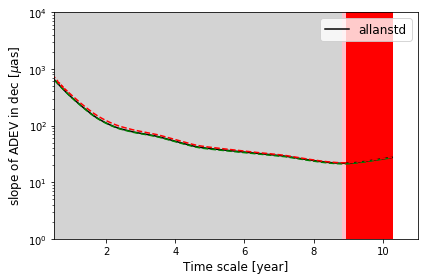

In [133]:
plt.figure()
# Calculate the slopes
slopes_dec = np.diff(np.log10(allanstd_dec_bar)) / np.diff(np.log10(tau_year_bar))
# Plot allanstd
plt.plot(tau_year_bar,allanstd_dec_bar,color='black',label='allanstd')
# Color background according to the slopes / noise type
plt.fill_between(tau_year_bar[1:], 1, 10**4, where= slopes_dec  < -0.25,color='lightgray',linewidth=1.0,zorder=1)
plt.fill_between(tau_year_bar[1:], 1, 10**4, where= (-0.25 <= slopes_dec ) & (slopes_dec  <= 0.25),color='pink',linewidth=1.0)
plt.fill_between(tau_year_bar[1:], 1, 10**4, where= slopes_dec  > 0.25,color='red',step='mid',linewidth=1.0)
# Plot confidence interval
plt.plot(tau_year_bar, allanstd_dec_bar + bottom_bar,color='green',linestyle='dashed')
plt.plot(tau_year_bar, allanstd_dec_bar + top_bar,color='red',linestyle='dashed')

plt.yscale('log')
plt.xlabel('Time scale [year]', fontsize=12)
plt.ylabel(r'slope of ADEV in dec [$\mu$as]', fontsize=12)
plt.legend(fontsize=12)
plt.ylim(1,10**4)
plt.xlim(0.5,11)
plt.tight_layout()

# Debugging RA data

In [ ]:
# === Parameters ===
y = df['RAcosDEC'].values
t = df['MJD'].values
error = df['Err. R.A. (micas)'].values
# Length of observation
N = len(y)

# m array where 3 < m < N/3 
m = np.arange(3,1+round(N//3),1)
# initial sampling time
tau0 =  np.mean(np.diff(t))
# steps
step = tau0

# Empty variance array
allanvar = []
# Empty tau values array 
tau = []

edfs = []

# Iterate over values of m
for k in range(len(m)): 
    # Sliding windows 
    left = min(t)
    right = min(t) + m[k]*tau0

    # Array for averages
    ybar = []

    # Array for amount of data points
    Nrray = []

    # Define no of windows with <= 2 data points
    nconstraint = 2

    # Check for missing windows 
    while right <= max(t):
        data_values = y[(t>=left) & (t<=right)]
        Ndata = len(data_values)
        Nrray.append(Ndata)

        if Ndata == 0:
            ybar.append(np.nan)
        else:
            if error is None: 
                avg = np.average(data_values)
                ybar.append(avg)
            else:
                weights_std = 1/error[(t>=left) & (t<=right)]**2
                avg = np.average(data_values, weights=weights_std)
                ybar.append(avg)
        left += step 
        right += step    

    # Define empty windows 
    Nrray = np.array(Nrray)
    ybar = np.array(ybar)

    D = len(ybar[Nrray<=nconstraint])
    M = len(ybar)
#     print(k,len(m),M,D)

    # Discard windows with too few data points
    ybar = ybar[Nrray>nconstraint]

    # Calculate allan var 
    outersum = []
    j = 0
    while j < M-2*m[k]+1-D:
        i = j
        innersum = []
        while i <= j+m[k]-1:
            innersum.append(ybar[i+m[k]]-ybar[i])
            i += 1
        outersum.append(0.5*(np.sum(innersum)/m[k])**2)
        j += 1


    # Calculate allan variance
    allanvar.append(np.sum(outersum)/(M-2*m[k]+1-D))

    # Calculate tau
    tau.append(tau0*m[k])

    # Calc edf
    try:
        alpha_int = tpy.noise_id(y,m[k])[0]
    except:
        alpha_int = 0
    print(m[k], alpha_int)
    if (alpha_int<3) and (alpha_int>-3):
        edf = tpy.edf_greenhall(alpha_int,2,m[k],N,overlapping=True)
    else:
        edf = tpy.edf_approx(N,m[k])
    
    edfs.append(edf)

# Calculate allan std dev
allanstd = np.sqrt(allanvar)

In [ ]:
edfs

In [ ]:
tau_year = [x/365.242198781 for x in tau]

In [ ]:
plt.figure()
# Calculate the slopes
slopes_dec = np.diff(np.log10(allanstd)) / np.diff(np.log10(allanstd))
# Plot allanstd
plt.plot(tau_dec_year,allanstd_dec_new,color='black',label='allanstd')
# Color background according to the slopes / noise type
plt.fill_between(tau_year[1:], 1, 10**4, where= slopes_dec  < -0.25,color='lightgray',linewidth=1.0,zorder=1)
plt.fill_between(tau_year[1:], 1, 10**4, where= (-0.25 <= slopes_dec ) & (slopes_dec  <= 0.25),color='pink',linewidth=1.0)
plt.fill_between(tau_year[1:], 1, 10**4, where= slopes_dec  > 0.25,color='red',step='mid',linewidth=1.0)
# Plot confidence interval
plt.plot(tau_dec_year, allanstd_dec_new + bottom,color='dimgrey',linestyle='dashed')
plt.plot(tau_dec_year, allanstd_dec_new + top,color='dimgrey',linestyle='dashed')

plt.yscale('log')
plt.xlabel('Time scale [year]', fontsize=fs)
plt.ylabel(r'slope of ADEV in RAcosdec [$\mu$as]', fontsize=fs)
plt.legend(fontsize=12)
plt.ylim(1,10**4)
plt.xlim(0.5,11)
plt.tight_layout()

In [ ]:
if np.isnan(test) == True:
    test = 0
    print(test)

# Using own func

In [ ]:
tpy.noise_id(y,3)

In [ ]:
def noise_id(y):
    dmin = 0 #default
    d = 0
    N = len(y)
    while True: 
        ybar = np.average(y)
        rnum = sum((y[i]-ybar)*(y[i+1]-ybar) for i in range (1,N-2))
        rdenom = sum((y[i]-ybar)**2 for i in range (1,N))
        r = rnum/rdenom
        delta = r/(1+r)
        if d>=dmin and delta < 0.25:
            alpha = -2*(delta+d)
            break
        else:
            y[1] = y[N] - y[N-1]
            N -= 1
            d += 1
    return alpha

In [ ]:
y = df['Dec. (micas)'].values

In [ ]:
noise_id(y)

In [ ]:
y

In [ ]:
dmin = 0 #default
d = 0
N = len(y)

In [ ]:
N